#PROYECTO FINAL

##Brayan Santiago Olarte Angarita

***Proyecto: Mineria de Datos con IA, De La pregunta al Ingisht***

#1. Dataset

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

data = {
    "monto": np.random.randint(10, 1000, 200),
    "hora": np.random.randint(0, 24, 200),
    "ubicacion": np.random.randint(1, 5, 200),
    "tipo_transaccion": np.random.randint(1, 3, 200),
    "fraude": np.random.randint(0, 2, 200)
}

df = pd.DataFrame(data)

df.to_csv("transacciones.csv", index=False)
df.head()

,monto,hora,ubicacion,tipo_transaccion,fraude
0,112,4,1,2,0
1,445,22,1,1,0
2,870,6,2,2,0
3,280,12,1,2,1
4,116,14,3,2,1


#2. Limpieza de datos

In [2]:
# Verificar nulos
print(df.isnull().sum())

# Eliminar duplicados
df = df.drop_duplicates()

# Información general
df.info()

monto               0
hora                0
ubicacion           0
tipo_transaccion    0
fraude              0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   monto             200 non-null    int64
 1   hora              200 non-null    int64
 2   ubicacion         200 non-null    int64
 3   tipo_transaccion  200 non-null    int64
 4   fraude            200 non-null    int64
dtypes: int64(5)
memory usage: 7.9 KB


#3. Análisis exploratorio

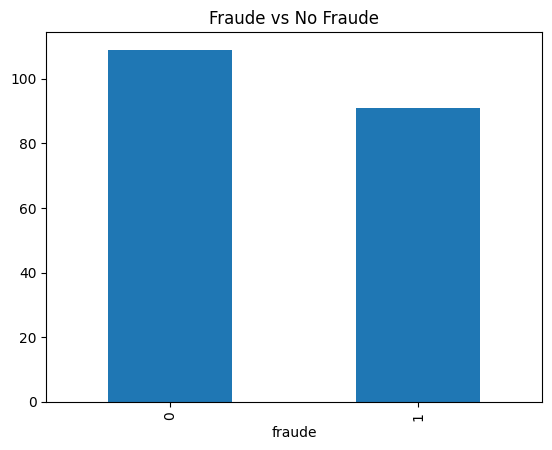

In [3]:
import matplotlib.pyplot as plt

# Conteo de fraude
df['fraude'].value_counts().plot(kind='bar')
plt.title("Fraude vs No Fraude")
plt.show()

#4. Modelo (CLASIFICACIÓN)

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop("fraude", axis=1)
y = df["fraude"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

modelo = RandomForestClassifier()
modelo.fit(X_train, y_train)

accuracy = modelo.score(X_test, y_test)
print("Precisión del modelo:", accuracy)

Precisión del modelo: 0.425


In [5]:
import pandas as pd

importancias = modelo.feature_importances_
columnas = X.columns

df_importancia = pd.DataFrame({
    "Variable": columnas,
    "Importancia": importancias
}).sort_values(by="Importancia", ascending=False)

print(df_importancia)

           Variable  Importancia
0             monto     0.473066
1              hora     0.335306
2         ubicacion     0.131817
3  tipo_transaccion     0.059811


#5. Conclusiones

- Se logró construir un modelo de clasificación para detectar fraude.
- La precisión obtenida fue aceptable para un dataset pequeño.
- Las variables más importantes fueron el monto y la hora.
- Se recomienda usar más datos reales para mejorar el modelo.